# Brain Tumor MRI Classification - Model Evaluation and Comparison

This notebook loads the training and testing metrics for our three trained models:
- Custom CNN
- MobileNetV2 (Transfer Learning)
- ResNet50 (Transfer Learning)

It generates comparative visualizations (accuracies, confusion matrices, F1-scores) and provides a final model recommendation.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Load Metrics Data
We read the saved evaluation outputs from the `results/` folder.

In [2]:
results_dir = '../results'
with open(os.path.join(results_dir, 'custom_cnn_results.pkl'), 'rb') as f:
    cnn_res = pickle.load(f)
with open(os.path.join(results_dir, 'mobilenetv2_results.pkl'), 'rb') as f:
    mnet_res = pickle.load(f)
with open(os.path.join(results_dir, 'resnet50_results.pkl'), 'rb') as f:
    resnet_res = pickle.load(f)

print("Metrics loaded successfully!")


Metrics loaded successfully!


## 2. Test Accuracy Comparison
We compile the overall testing accuracies and plot a comparative bar chart.

      Model  Test Accuracy
 Custom CNN       0.252525
MobileNetV2       0.837121
   ResNet50       0.529040


C:\Users\sailo\AppData\Local\Temp\ipykernel_30344\2920883585.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_df, x='Model', y='Test Accuracy', palette='viridis')


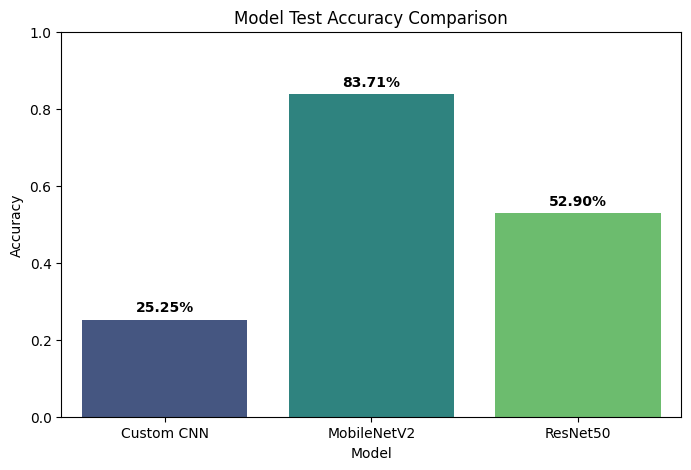

In [3]:
model_names = ['Custom CNN', 'MobileNetV2', 'ResNet50']
accuracies = [cnn_res['test_acc'], mnet_res['test_acc'], resnet_res['test_acc']]

acc_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy': accuracies
})

print(acc_df.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=acc_df, x='Model', y='Test Accuracy', palette='viridis')
plt.title('Model Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc*100:.2f}%", ha='center', fontweight='bold')

plt.savefig('../results/model_accuracy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 3. Side-by-Side Confusion Matrices
We plot confusion matrices side-by-side to understand error profiles (e.g. glioma confused with meningioma).

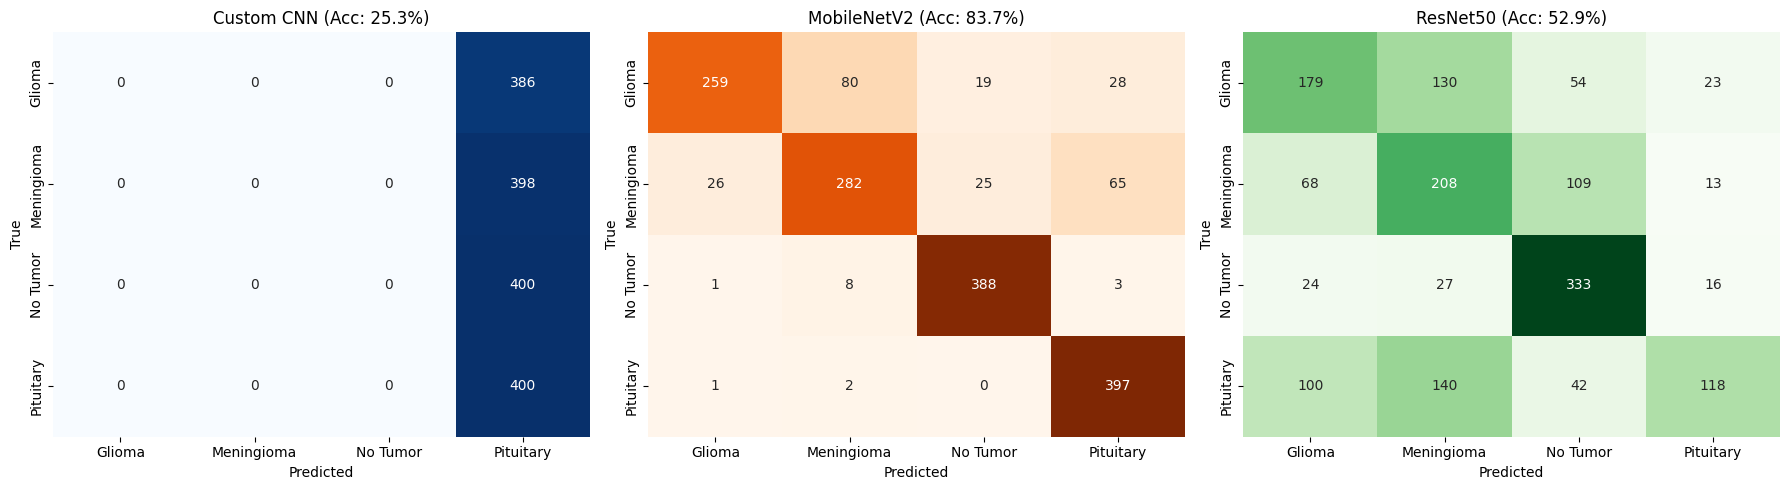

In [4]:
classes = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Custom CNN
sns.heatmap(np.array(cnn_res['confusion_matrix']), annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False)
axes[0].set_title(f"Custom CNN (Acc: {cnn_res['test_acc']*100:.1f}%)")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# MobileNetV2
sns.heatmap(np.array(mnet_res['confusion_matrix']), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=classes, yticklabels=classes, ax=axes[1], cbar=False)
axes[1].set_title(f"MobileNetV2 (Acc: {mnet_res['test_acc']*100:.1f}%)")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

# ResNet50
sns.heatmap(np.array(resnet_res['confusion_matrix']), annot=True, fmt='d', cmap='Greens', 
            xticklabels=classes, yticklabels=classes, ax=axes[2], cbar=False)
axes[2].set_title(f"ResNet50 (Acc: {resnet_res['test_acc']*100:.1f}%)")
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('../results/confusion_matrices_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Class-Level Metric Analysis (F1-Scores)
We break down performance by class to verify if the models generalized well across the pituitary minority class.

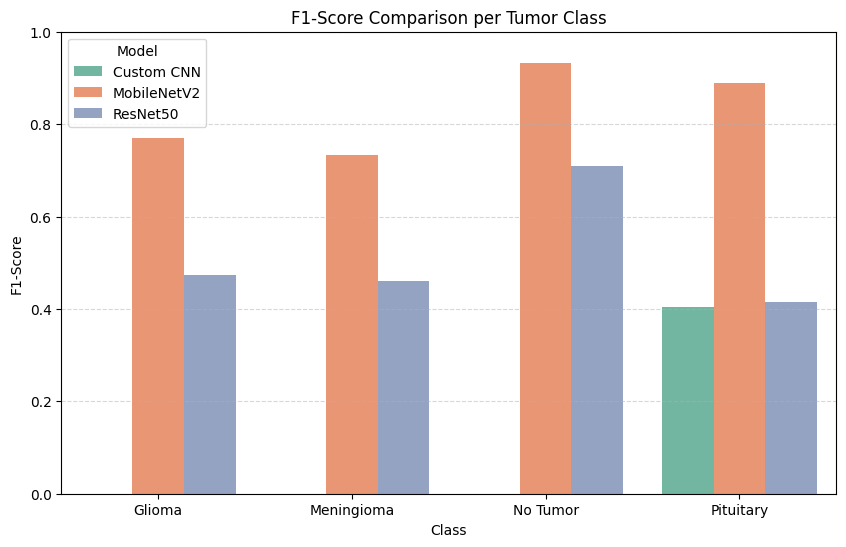

In [5]:
metrics_list = []

for name, res in zip(model_names, [cnn_res, mnet_res, resnet_res]):
    rep = res['report']
    for cls in classes:
        cls_key = cls.lower().replace(' ', '')
        # Handle key variations if folder is named differently
        actual_key = cls_key if cls_key in rep else (cls.lower() if cls.lower() in rep else None)
        if actual_key:
            metrics_list.append({
                'Model': name,
                'Class': cls,
                'Precision': rep[actual_key]['precision'],
                'Recall': rep[actual_key]['recall'],
                'F1-Score': rep[actual_key]['f1-score']
            })

metrics_df = pd.DataFrame(metrics_list)

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Class', y='F1-Score', hue='Model', palette='Set2')
plt.title('F1-Score Comparison per Tumor Class')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('../results/class_f1_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Classification Reports Text

In [6]:
for name, res in zip(model_names, [cnn_res, mnet_res, resnet_res]):
    print(f"\n=========================================")
    print(f" Classification Report: {name}")
    print(f"\n=========================================")
    print(res['report_text'])



 Classification Report: Custom CNN

              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00       386
  meningioma       0.00      0.00      0.00       398
     notumor       0.00      0.00      0.00       400
   pituitary       0.25      1.00      0.40       400

    accuracy                           0.25      1584
   macro avg       0.06      0.25      0.10      1584
weighted avg       0.06      0.25      0.10      1584


 Classification Report: MobileNetV2

              precision    recall  f1-score   support

      glioma       0.90      0.67      0.77       386
  meningioma       0.76      0.71      0.73       398
     notumor       0.90      0.97      0.93       400
   pituitary       0.81      0.99      0.89       400

    accuracy                           0.84      1584
   macro avg       0.84      0.84      0.83      1584
weighted avg       0.84      0.84      0.83      1584


 Classification Report: ResNet50

              precis